# 多分类 vs 多标签：同一份手写数字数据上的对照

同一个数据集、同一套网络骨架，只换四样东西：**任务定义 → 输出层 → 损失函数 → 指标**。

判断口诀：**一个输入能不能同时属于多个类别？** 不能则多分类，能则多标签。


## 核心对比

| 维度 | 多分类 | 多标签 |
|---|---|---|
| 标签关系 | 互斥，只有一个正确 | 独立，可同时成立 |
| 输出层 | softmax，输出加和为 1 | 每个标签一个 sigmoid，各自独立 |
| 输出维度 | 类别数 = 10 | 标签数 = 4 |
| 损失 | SparseCategoricalCrossentropy | BinaryCrossentropy |
| 判定 | argmax 取最大 | 每个输出各自比 0.5 |
| 指标 | accuracy 可直接用 | accuracy 不可用，要逐元素 BinaryAccuracy |

两个任务都采用 `linear` 输出层 + `from_logits=True`，把 softmax / sigmoid 折进损失函数内部，与 `mutil_class.py`、`multi_label_classification.py` 保持一致。


In [14]:
%matplotlib inline
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.io import loadmat

# 固定随机种子：让权重初始化、batch 打乱等随机过程每次运行都一样，训练结果可复现
tf.keras.utils.set_random_seed(0)
# 关闭非确定性算子，避免多线程累加顺序不同带来的微小抖动（TensorFlow >= 2.9）
tf.config.experimental.enable_op_determinism()

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# notebook 里没有 __file__，用当前工作目录定位数据文件（notebook 与 .mat 同目录）
data_path = os.path.join(os.getcwd(), 'ex3data1.mat')
data = loadmat(data_path)
X = data['X']             # (5000, 400)，每行是一张 20x20 的图展平成 400 维
y = data['y'].flatten()   # (5000,)，取值 1~10，其中 10 表示数字 0
digit = y % 10            # (5000,)，映射成 0~9

print('数据文件:', data_path)
print('X:', X.shape, ' y:', y.shape)


数据文件: d:\workspace\machine-learning\08_mutil_class\ex3data1.mat
X: (5000, 400)  y: (5000,)


先确认数据长什么样：每行 400 个数就是一张 20x20 的灰度图。


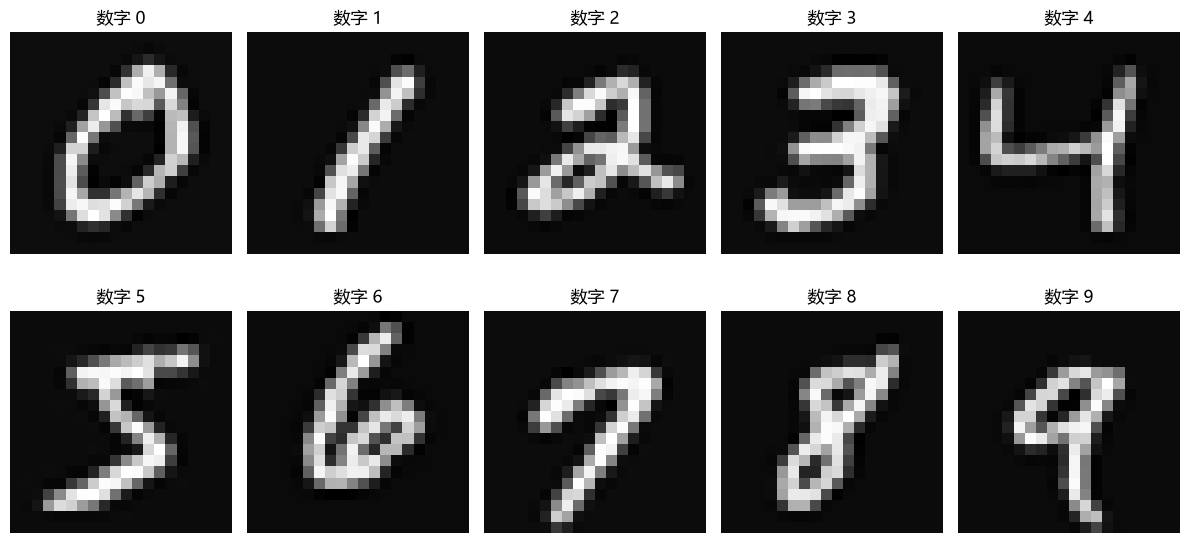

In [15]:
plt.figure(figsize=(12, 6))
for d in range(10):
    idx = np.where(digit == d)[0][0]     # 每个数字抽第一个样本
    img = X[idx].reshape(20, 20).T       # .mat 是按列优先展平的，转置回来才是正的
    plt.subplot(2, 5, d + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'数字 {d}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 任务定义：同一个输入，两种答案

多分类的答案是「这是几」；多标签的答案是「4 个判断题各是真是假」。


In [16]:
# 多分类标签：一个取值 0~9 的整数
y_multi_class = digit

# 多标签标签：4 个互相独立的 0/1 判断
label_big = (digit >= 5).astype(int)                    # 是不是大数字
label_even = (digit % 2 == 0).astype(int)               # 是不是偶数
label_prime = np.isin(digit, [2, 3, 5, 7]).astype(int)  # 是不是质数
label_loop = np.isin(digit, [0, 6, 8, 9]).astype(int)   # 是不是含闭环
Y_multi_label = np.column_stack([label_big, label_even, label_prime, label_loop])
label_names = ['大数字', '偶数', '质数', '含闭环']

for d in range(10):
    row = Y_multi_label[np.where(digit == d)[0][0]]
    print(f'数字 {d} -> 多分类答案 {d}；多标签答案 {row}，命中 {row.sum()} 个标签')

print()
print('4 个标签的正样本比例:', Y_multi_label.mean(axis=0).round(3))
print('每个样本平均命中标签数:', round(float(Y_multi_label.sum(axis=1).mean()), 2))


数字 0 -> 多分类答案 0；多标签答案 [0 1 0 1]，命中 2 个标签
数字 1 -> 多分类答案 1；多标签答案 [0 0 0 0]，命中 0 个标签
数字 2 -> 多分类答案 2；多标签答案 [0 1 1 0]，命中 2 个标签
数字 3 -> 多分类答案 3；多标签答案 [0 0 1 0]，命中 1 个标签
数字 4 -> 多分类答案 4；多标签答案 [0 1 0 0]，命中 1 个标签
数字 5 -> 多分类答案 5；多标签答案 [1 0 1 0]，命中 2 个标签
数字 6 -> 多分类答案 6；多标签答案 [1 1 0 1]，命中 3 个标签
数字 7 -> 多分类答案 7；多标签答案 [1 0 1 0]，命中 2 个标签
数字 8 -> 多分类答案 8；多标签答案 [1 1 0 1]，命中 3 个标签
数字 9 -> 多分类答案 9；多标签答案 [1 0 0 1]，命中 2 个标签

4 个标签的正样本比例: [0.5 0.5 0.4 0.4]
每个样本平均命中标签数: 1.8


## 数据划分：两个任务共用同一套划分

先切出测试集，再从剩下的切出验证集，按数字类别分层。**共用同一套索引**才能公平对照。

注意：共用的只是**样本索引**，不是 y。两个任务的标签形状和构造都不同（多分类是 0~9 的整数，多标签是 (m, 4) 的 0/1 矩阵），各自独立生成，只是落在同一批图片上。
这样两个任务的测试集就是同一批样本，0.92 和 0.9573 之间的差异才能归因于任务定义，而不是抽样运气。


In [17]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(X))
idx_train_val, idx_test = train_test_split(indices, test_size=0.15, random_state=42, stratify=digit)
idx_train, idx_val = train_test_split(idx_train_val, test_size=0.15 / 0.85,
                                      random_state=42, stratify=digit[idx_train_val])

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y_multi_class[idx_train], y_multi_class[idx_val], y_multi_class[idx_test]
Y_train, Y_val, Y_test = Y_multi_label[idx_train], Y_multi_label[idx_val], Y_multi_label[idx_test]

print('训练集:', X_train.shape, ' 验证集:', X_val.shape, ' 测试集:', X_test.shape)
print('多标签训练集各标签正样本数:', Y_train.sum(axis=0))


训练集: (3500, 400)  验证集: (750, 400)  测试集: (750, 400)
多标签训练集各标签正样本数: [1750 1750 1400 1400]


## 任务一：多分类（10 类互斥）

- 输出层：10 个神经元 + `linear`，配合 `from_logits=True`
- 损失：`SparseCategoricalCrossentropy`（标签是整数，不用 one-hot）
- 指标：这里 `accuracy` 是对的 —— 10 类互斥，argmax 出来的就是预测类别


In [18]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model_mc = Sequential([
    Dense(units=25, activation='relu', input_shape=(X.shape[1],)),
    Dense(units=15, activation='relu'),
    Dense(units=10, activation='linear'),
])
model_mc.compile(loss=SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
history_mc = model_mc.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)


Epoch 1/100


c:\ProgramData\Anaconda3\envs\python3.13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4254 - loss: 1.7913 - val_accuracy: 0.6547 - val_loss: 1.3153
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7326 - loss: 0.9963 - val_accuracy: 0.8080 - val_loss: 0.7826
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8340 - loss: 0.6518 - val_accuracy: 0.8453 - val_loss: 0.6004
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.5146 - val_accuracy: 0.8627 - val_loss: 0.5120
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8803 - loss: 0.4372 - val_accuracy: 0.8733 - val_loss: 0.4597
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8920 - loss: 0.3866 - val_accuracy: 0.8813 - val_loss: 0.4247
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8994 - loss: 0.3500 - val_accuracy: 0.8880 - val_loss: 0.3987
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9094 - loss: 0.3215 - val_accuracy: 0.8933

loss 与 accuracy 曲线（训练集 vs 验证集）。


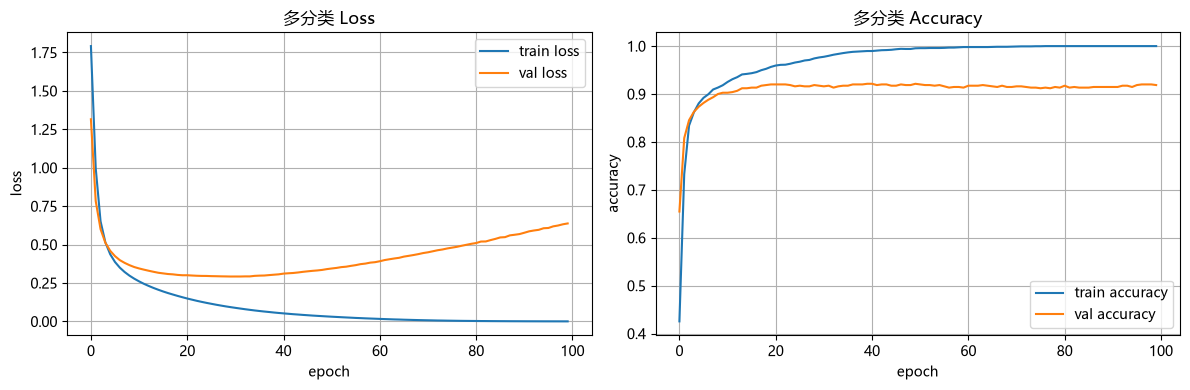

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mc.history['loss'], label='train loss')
axes[0].plot(history_mc.history['val_loss'], label='val loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].set_title('多分类 Loss')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_mc.history['accuracy'], label='train accuracy')
axes[1].plot(history_mc.history['val_accuracy'], label='val accuracy')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].set_title('多分类 Accuracy')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()


### 测试案例：argmax 只给出唯一答案

从测试集里挑一张模型判对的图来看输出格式。多分类必须用 `argmax` 选一个类，而不是逐个比阈值。


多分类 测试集 loss: 0.7191, accuracy: 0.9333


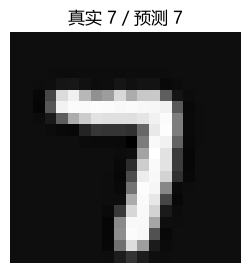

概率最高的 3 个类别: [7 3 2] 对应概率 [1. 0. 0.]


In [20]:
test_loss_mc, test_acc_mc = model_mc.evaluate(X_test, y_test, verbose=0)
print(f'多分类 测试集 loss: {test_loss_mc:.4f}, accuracy: {test_acc_mc:.4f}')

# 演示样本：从测试集里挑第一张模型判对的图。
# 不直接随机抽，是因为随机抽有约 7% 的概率正好抽到错例，看起来像模型很差；
# 整体表现看上面的 accuracy 就够，这里只用来看输出格式。
probs_all_mc = tf.nn.softmax(model_mc.predict(X_test, verbose=0)).numpy()
pred_all_mc = probs_all_mc.argmax(axis=1)
i = int(np.where(pred_all_mc == y_test)[0][0])
probs_mc = probs_all_mc[i]
pred_mc = int(probs_mc.argmax())

plt.figure(figsize=(3, 3))
plt.imshow(X_test[i].reshape(20, 20).T, cmap='gray')
plt.title(f'真实 {y_test[i]} / 预测 {pred_mc}')
plt.axis('off')
plt.show()

top3 = np.argsort(probs_mc)[::-1][:3]
print('概率最高的 3 个类别:', top3, '对应概率', probs_mc[top3].round(4))


## 任务二：多标签（4 个标签各自独立）

- 输出层：4 个神经元 + `linear`，配合 `from_logits=True`
- 损失：`BinaryCrossentropy`，每个标签各自算一次二分类损失
- 指标：**不能用 `accuracy`** —— Keras 会把它当成多分类用 argmax 比较，报出的数字和标签对错无关。要用 `BinaryAccuracy` 逐个标签判断


In [21]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_ml = Sequential([
    Dense(units=25, activation='relu', input_shape=(X.shape[1],)),
    Dense(units=15, activation='relu'),
    Dense(units=4, activation='linear'),
])
model_ml.compile(loss=BinaryCrossentropy(from_logits=True),
                 metrics=[BinaryAccuracy(name='elem_acc')],
                 optimizer=Adam(learning_rate=0.001))

# 验证集损失连续 10 轮不降就停，并回滚到最好的那轮权重
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_ml = model_ml.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                          epochs=100, callbacks=[early_stop])


Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elem_acc: 0.7079 - loss: 0.5786 - val_elem_acc: 0.8050 - val_loss: 0.4609
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.8466 - loss: 0.3785 - val_elem_acc: 0.8583 - val_loss: 0.3379
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.8846 - loss: 0.2873 - val_elem_acc: 0.8860 - val_loss: 0.2734
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.9094 - loss: 0.2315 - val_elem_acc: 0.9093 - val_loss: 0.2313
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.9272 - loss: 0.1930 - val_elem_acc: 0.9250 - val_loss: 0.2017
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.9384 - loss: 0.1659 - val_elem_acc: 0.9343 - val_loss: 0.1826
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.9460 - loss: 0.1463 - val_elem_acc: 0.9390 - val_loss: 0.1688
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - elem_acc: 0.9514 - loss: 0.1313 - val_elem

loss 与逐元素准确率曲线（训练集 vs 验证集）。


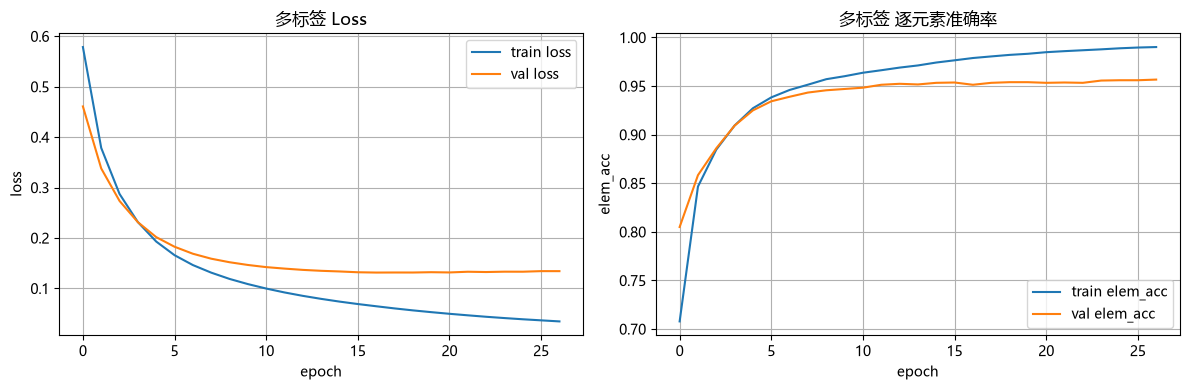

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_ml.history['loss'], label='train loss')
axes[0].plot(history_ml.history['val_loss'], label='val loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].set_title('多标签 Loss')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_ml.history['elem_acc'], label='train elem_acc')
axes[1].plot(history_ml.history['val_elem_acc'], label='val elem_acc')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('elem_acc'); axes[1].set_title('多标签 逐元素准确率')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()


### 评估：逐元素准确率必须和基线对照

4 个标签的正样本比例约 0.5 / 0.5 / 0.4 / 0.4，什么都不学、全预测 0 也能拿到约 **0.55** 的逐元素准确率。所以这个数字不能单独看。

再统计「一个样本命中几个标签」，直接回答多标签特有的问题。


多标签 测试集 loss: 0.1485, 逐元素准确率: 0.9513
全零预测的逐元素准确率基线: 0.5500
平均命中标签数: 真实 1.80 个, 预测 1.81 个


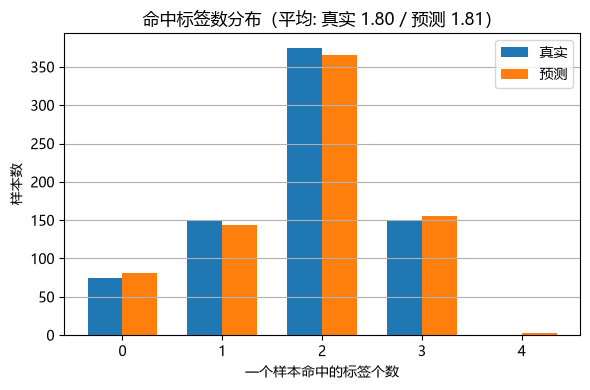

In [23]:
test_loss_ml, test_elem_acc = model_ml.evaluate(X_test, Y_test, verbose=0)
all_zero_acc = 1 - Y_test.mean()
print(f'多标签 测试集 loss: {test_loss_ml:.4f}, 逐元素准确率: {test_elem_acc:.4f}')
print(f'全零预测的逐元素准确率基线: {all_zero_acc:.4f}')

# 输出层是 linear，先 sigmoid 转概率，再按 0.5 判定每个标签是否为 1
test_probs = tf.sigmoid(model_ml.predict(X_test, verbose=0)).numpy()
pred_counts = (test_probs >= 0.5).sum(axis=1)   # 预测命中的标签个数
true_counts = Y_test.sum(axis=1).astype(int)    # 真实命中的标签个数
print(f'平均命中标签数: 真实 {true_counts.mean():.2f} 个, 预测 {pred_counts.mean():.2f} 个')

plt.figure(figsize=(6, 4))
ks = np.arange(5)
width = 0.35
plt.bar(ks - width / 2, [(true_counts == k).sum() for k in ks], width, label='真实')
plt.bar(ks + width / 2, [(pred_counts == k).sum() for k in ks], width, label='预测')
plt.xlabel('一个样本命中的标签个数')
plt.ylabel('样本数')
plt.title(f'命中标签数分布（平均: 真实 {true_counts.mean():.2f} / 预测 {pred_counts.mean():.2f}）')
plt.xticks(ks)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


### 测试案例：同一个输入，两种答案的差别

还是上面那个测试样本，看多分类只给一个数字，多标签给出 4 位的判定。

注意：两个任务是各自独立训练的模型，完全可能出现「多分类判对、多标签多报了一个标签」的情况。
多标签出错的方式通常是「多报或漏报某个标签」，而不是整条判错，这正是它和多分类在评估上的核心差异。


In [24]:
logits_ml = model_ml.predict(X_test[[i]], verbose=0)[0]
probs_ml = tf.sigmoid(logits_ml).numpy()
pred_ml = (probs_ml >= 0.5).astype(int)

print('真实:  多分类 =', int(y_test[i]), '；多标签 =', Y_test[i], f'（命中 {Y_test[i].sum()} 个）')
print('预测:  多分类 =', pred_mc, '；多标签 =', pred_ml, f'（命中 {pred_ml.sum()} 个）')
print()
for name, p, t in zip(label_names, probs_ml, Y_test[i]):
    print(f'  {name}: 预测概率 {p:.4f} -> {int(p >= 0.5)}，真实 {t}')


真实:  多分类 = 7 ；多标签 = [1 0 1 0] （命中 2 个）
预测:  多分类 = 7 ；多标签 = [1 0 1 0] （命中 2 个）

  大数字: 预测概率 1.0000 -> 1，真实 1
  偶数: 预测概率 0.0000 -> 0，真实 0
  质数: 预测概率 1.0000 -> 1，真实 1
  含闭环: 预测概率 0.0000 -> 0，真实 0


In [25]:
print(f'多分类 测试集 accuracy      : {test_acc_mc:.4f}')
print(f'多标签 测试集 逐元素准确率 : {test_elem_acc:.4f}  (全零基线 {all_zero_acc:.4f})')
print(f'多标签 平均命中标签数      : 真实 {true_counts.mean():.2f} / 预测 {pred_counts.mean():.2f}')


多分类 测试集 accuracy      : 0.9333
多标签 测试集 逐元素准确率 : 0.9513  (全零基线 0.5500)
多标签 平均命中标签数      : 真实 1.80 / 预测 1.81


## 小结

| 同一份数据 | 多分类 | 多标签 |
|---|---|---|
| 输出层 | 10 个神经元 | 4 个神经元 |
| 损失 | SparseCategoricalCrossentropy | BinaryCrossentropy |
| 判定 | argmax | 每个标签比 0.5 |
| 指标 | accuracy | BinaryAccuracy |
| 能否「一个都不属于」 | 不行 | 可以（数字 1 命中 0 个标签） |

踩坑清单：

1. 多标签用 `metrics=['accuracy']`：Keras 当成多分类按 argmax 比较，结果没有意义。
2. 多标签用 softmax + categorical 交叉熵：会强迫各标签抢概率，等于假设它们互斥。
3. 忘了基线：多标签的逐元素准确率不和全零基线（约 0.55）对比就没有意义。
4. `from_logits=True` 配 `sigmoid` 输出层：Keras 会警告，属于错误搭配。要么 `linear` + `from_logits=True`，要么 `sigmoid` + `from_logits=False`。

只要「一个样本能同时属于多个类别」，输出层、损失、指标这三样就必须一起换。
